# 01: Rigorous Exploratory Data Analysis (EDA)

This notebook covers Phase 1: Data Acquisition and EDA with a focus on data quality, distributions, relationships, and fairness pre-checks.

## 1. Data Quality Audit

Understand the raw data, identifying duplicates, biologically implausible zeros, and effective data loss.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")

# Load data
df = pd.read_csv('../data/pima_diabetes.csv')

# 1.1 Schema/Duplicates
n_duplicates = df.duplicated().sum()
if n_duplicates == 0:
    print("a. No duplicate rows found.")
else:
    print(f"a. Found {n_duplicates} duplicate rows.")

print(f"Dataset Shape: {df.shape}")

# 1.2 Identify physiologically impossible zeros
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print(f"b. Features checked for biologically implausible zeros: {', '.join(cols_with_zeros)}")

zero_stats = df[cols_with_zeros].apply(lambda x: (x == 0).sum())
zero_pct = (zero_stats / len(df)) * 100

quality_df = pd.DataFrame({'Zero Count': zero_stats, 'Zero %': zero_pct.round(2)})
display(quality_df)

# 1.3 Effective Data Loss if Zeros are dropped
rows_with_any_zero = df[cols_with_zeros].apply(lambda x: (x == 0).any(), axis=1).sum()
loss_pct = (rows_with_any_zero / len(df)) * 100
print(f"c. We would lose {rows_with_any_zero} datapoints ({loss_pct:.2f}% of data) if zeros are treated as missing and dropped.")

a. No duplicate rows found.
Dataset Shape: (768, 9)
b. Features checked for biologically implausible zeros: Glucose, BloodPressure, SkinThickness, Insulin, BMI


,Zero Count,Zero %
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


c. We would lose 376 datapoints (48.96% of data) if zeros are treated as missing and dropped.


**Observations: Data Quality**
*   **Duplicates**: The dataset is clean of duplicate records.
*   **Physiological Zeros**: A massive percentage of `Insulin` (48.7%) and `SkinThickness` (29.56%) values are zero. These are not physically possible and must be treated as missing values (NaN).
*   **Data Integrity**: If we were to drop rows containing any of these zeros, we would lose approximately half the dataset. This highlights the absolute necessity of a robust **imputation strategy** (like KNN Imputation) rather than simple row deletion.

## 2. Target Distribution

Set the baseline for modeling decisions.

Class 0 (Healthy): 500 points
Class 1 (Diabetic): 268 points


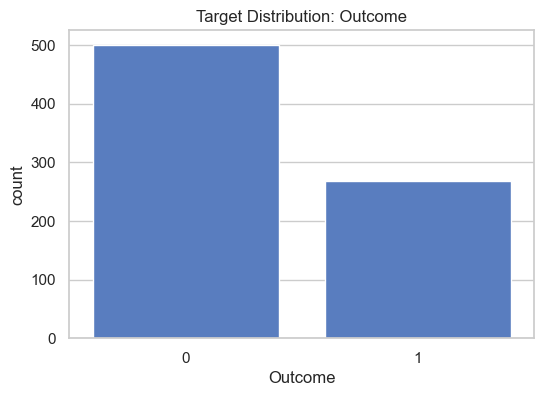

Naive (Majority Class) Baseline Accuracy: 65.10%


In [2]:
counts = df['Outcome'].value_counts().sort_index()
percent = df['Outcome'].value_counts(normalize=True).sort_index() * 100

print(f"Class 0 (Healthy): {counts[0]} points")
print(f"Class 1 (Diabetic): {counts[1]} points")

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Target Distribution: Outcome')
plt.show()

print(f"Naive (Majority Class) Baseline Accuracy: {percent[0]:.2f}%")

**Observations: Target Distribution**
*   The dataset exhibits a **35/65 class split**. While not extremely imbalanced, the minority class (Diabetic) is significantly smaller.
*   Any model achieving less than **65.1% accuracy** is performing worse than a random guesser that always predicts 'Healthy'.
*   We will use **stratified sampling** and **SMOTE** (oversampling) in the preprocessing phase to ensure the model learns to identify the minority class effectively.

## 3. Feature Distributions & Outliers

Examine shape, skewness, and outliers individually.

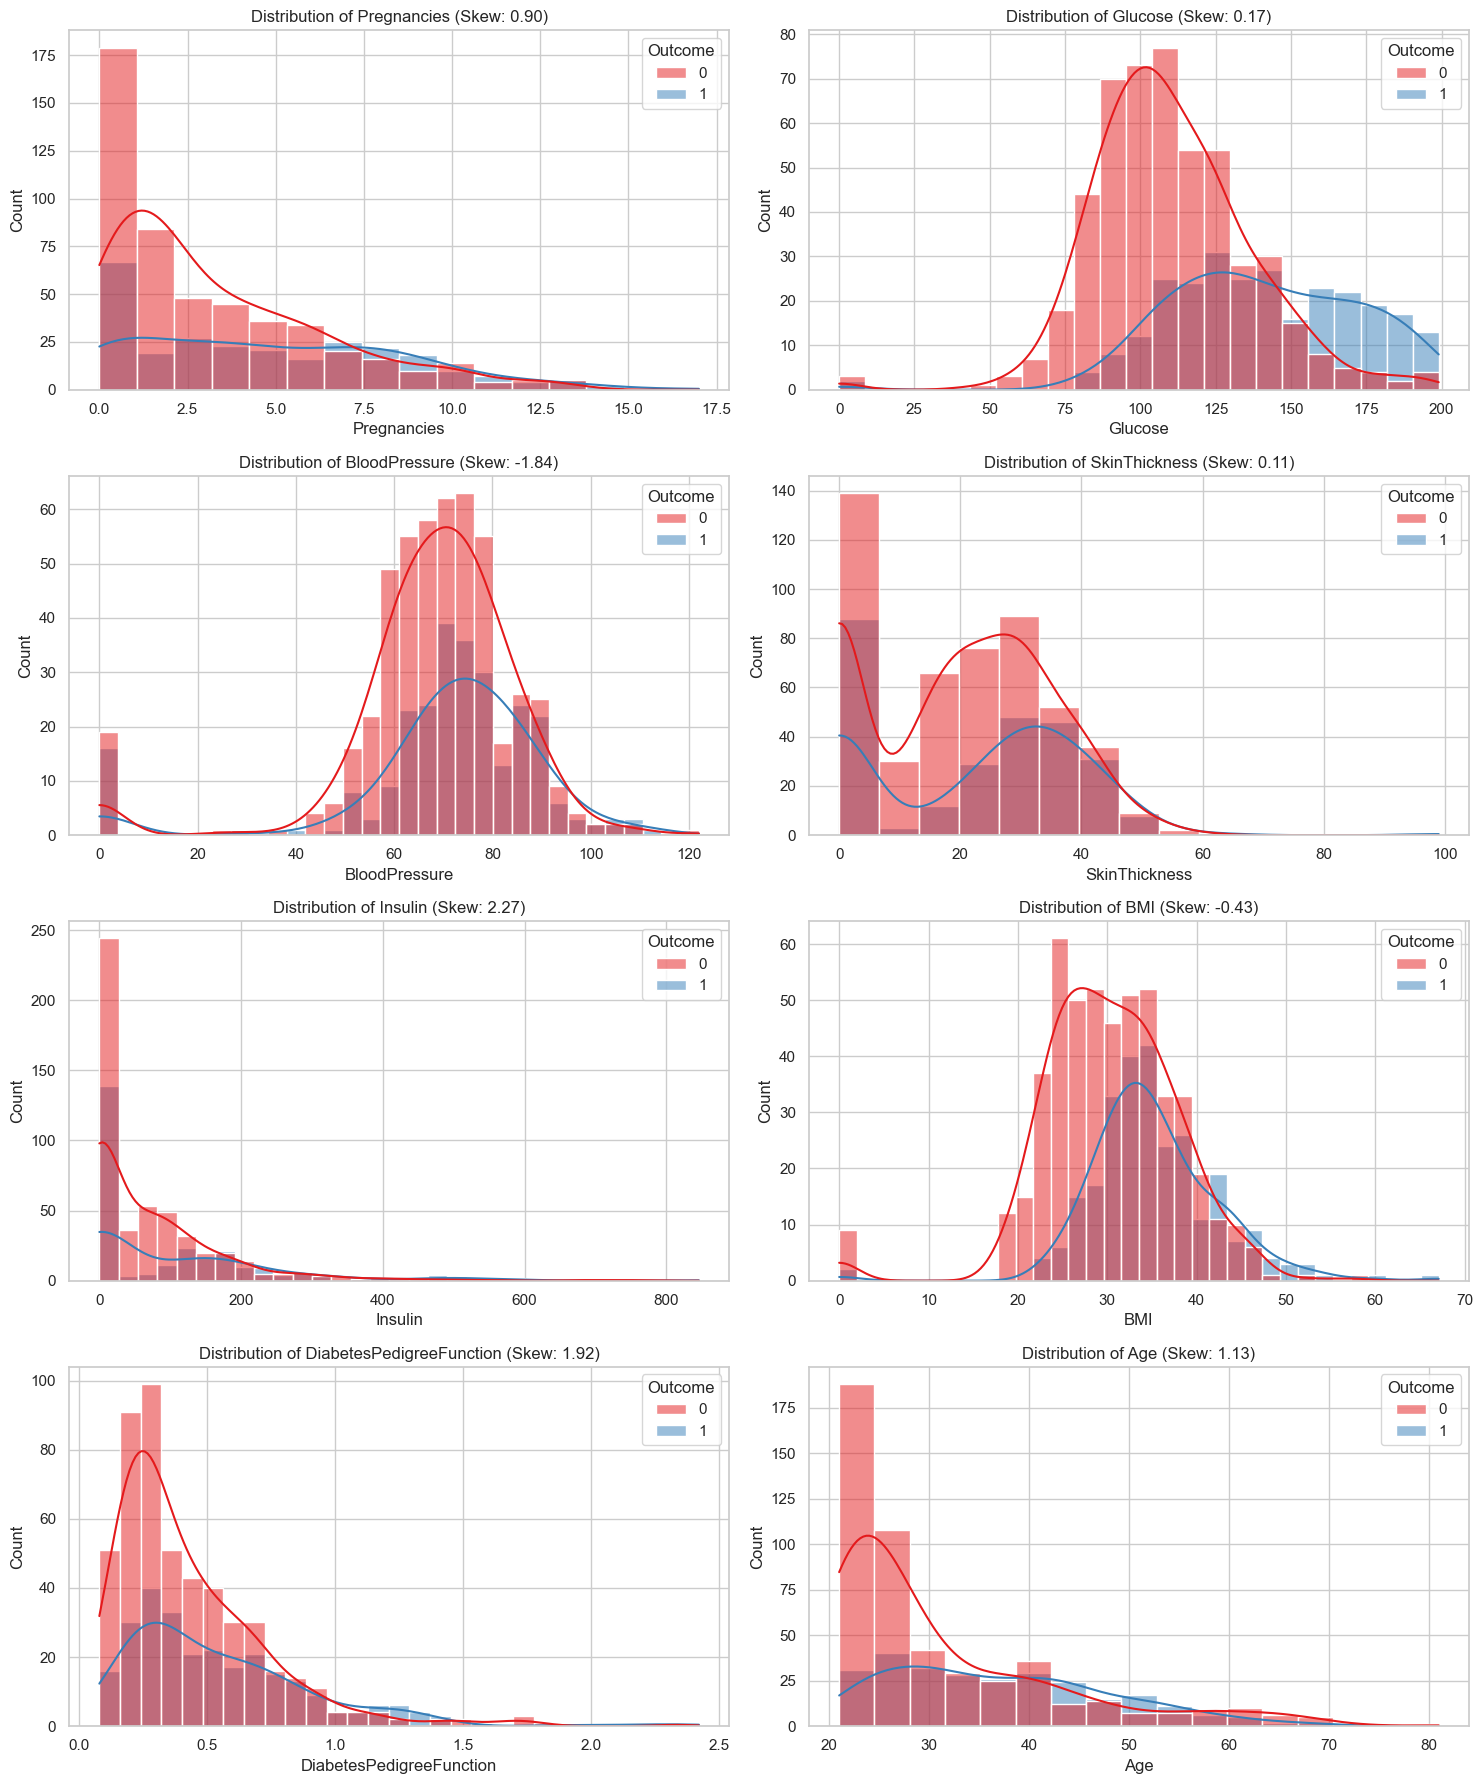

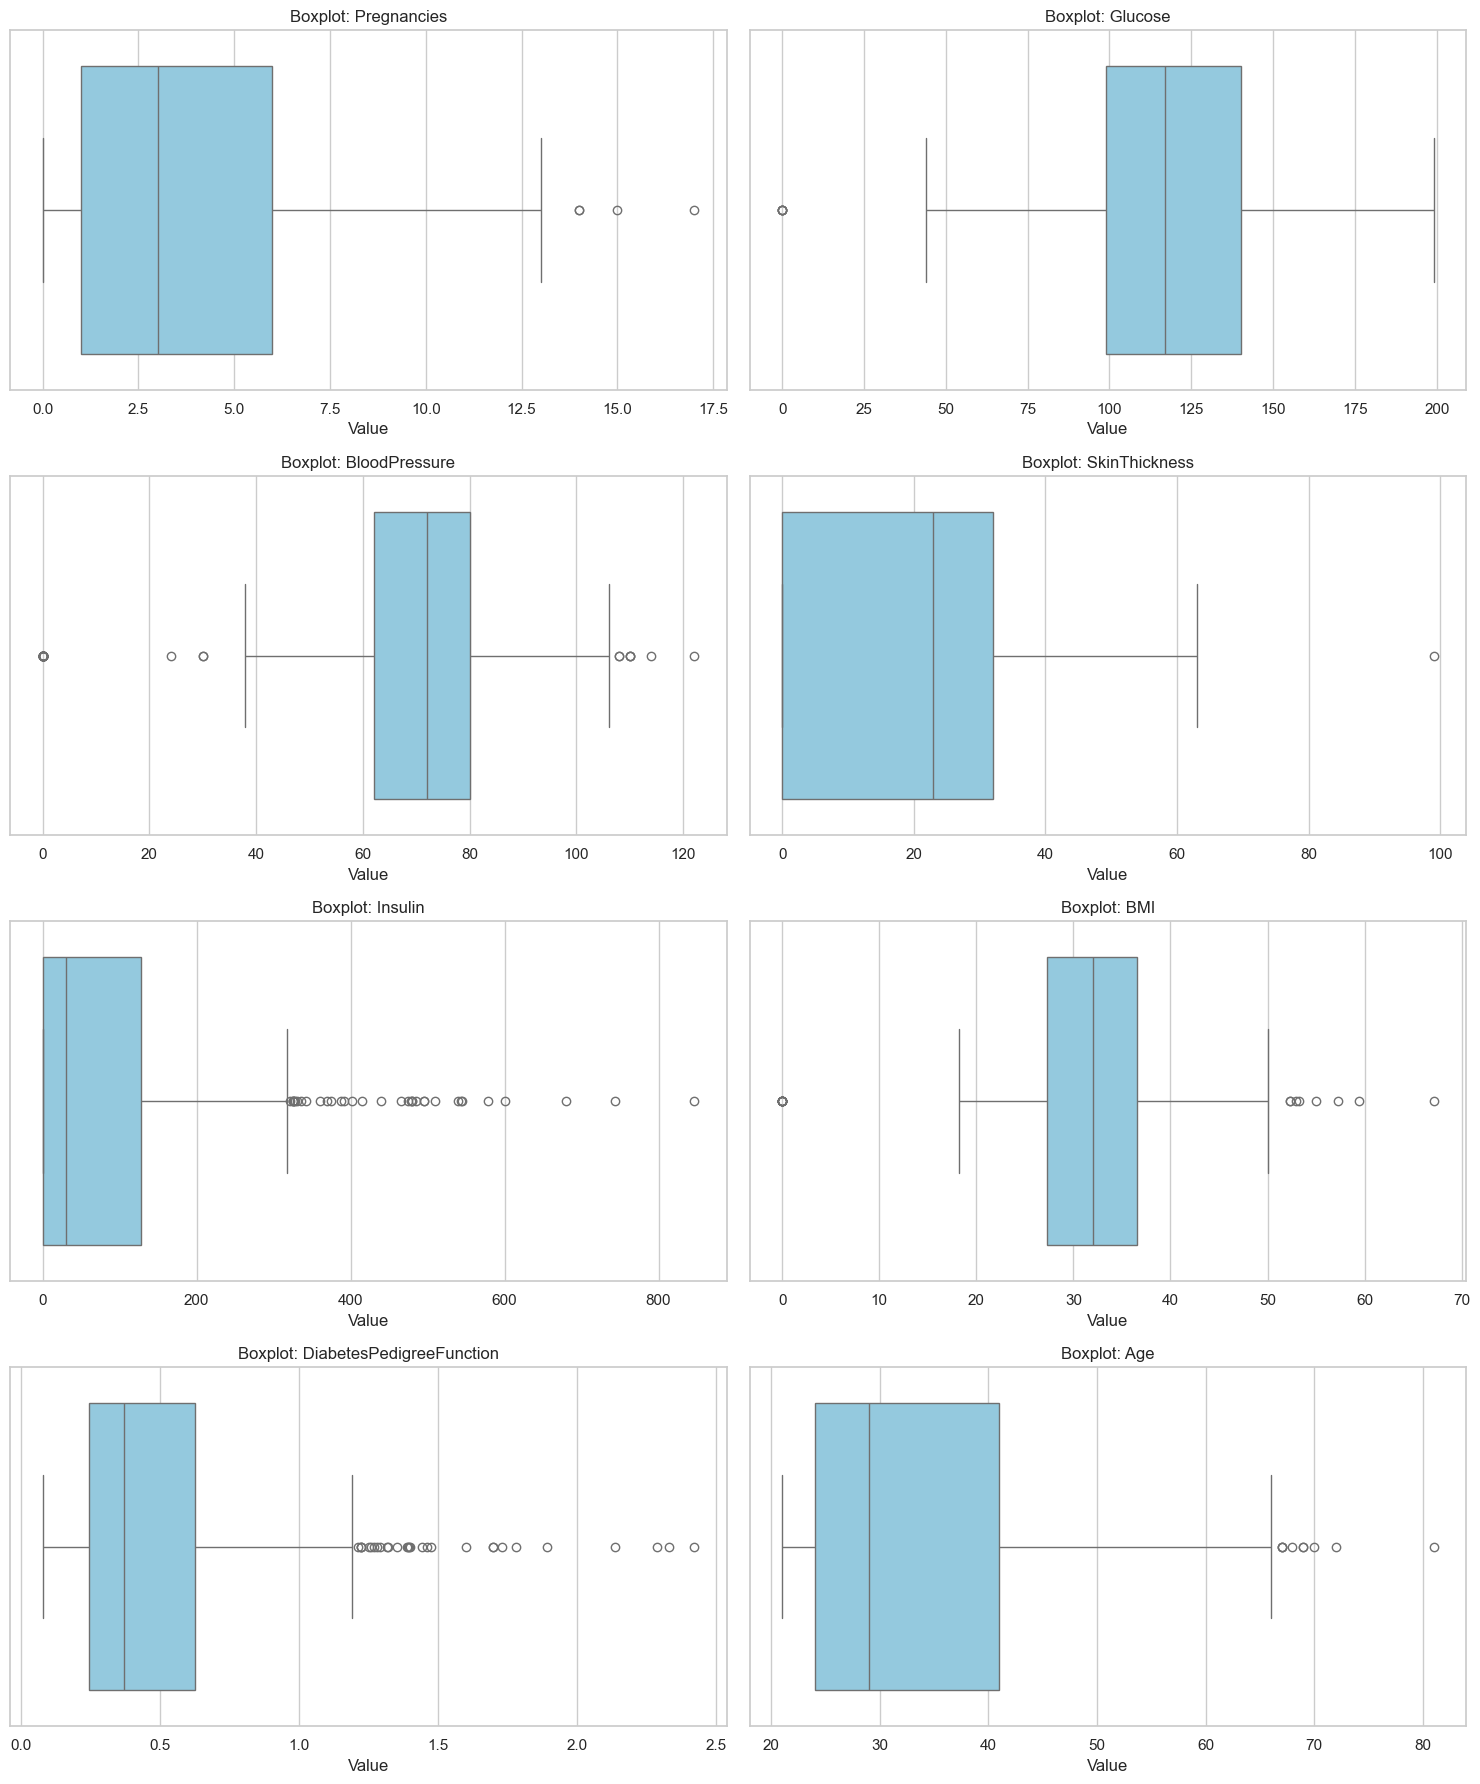

In [3]:
features = df.columns.drop('Outcome')
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    # Distribution plot split by Outcome
    sns.histplot(data=df, x=col, hue='Outcome', kde=True, ax=axes[i], palette='Set1', alpha=0.5)
    axes[i].set_title(f'Distribution of {col} (Skew: {df[col].skew():.2f})')

plt.tight_layout()
plt.show()

# 3.2 Individual Boxplots to see specific ranges/units
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_xlabel('Value')

plt.tight_layout()
plt.show()

**How to interpret the Box Plot:**
*   **Center Line**: The median of the data.
*   **Box (IQR)**: The Interquartile Range (25th to 75th percentile). 50% of the data falls within this box.
*   **Whiskers**: Extend to 1.5x the IQR. Points beyond these are plotted individually as **outliers**.
*   **Interpretation**: In these split plots, we can see the exact scale for each feature. For example, `Insulin` peaks near 800 while `BMI` peaks near 60. This clear visualization helps identify which features require scaling or clipping.

**Observations: Feature Distributions**
*   **Insulin** has a massive right skew (2.27) and the most significant outliers. We might need log-transformation or thresholding here.
*   **Glucose** shows a very clear separation: the "Healthy" distribution peaks significantly lower and is narrower than the "Diabetic" distribution.
*   **Pregnancies** shows a long tail. While 17 pregnancies is high, it is clinically possible and likely represents a real edge case rather than an error.

## 4. Relationships Between Features

Catch multicollinearity and discover interaction potential.

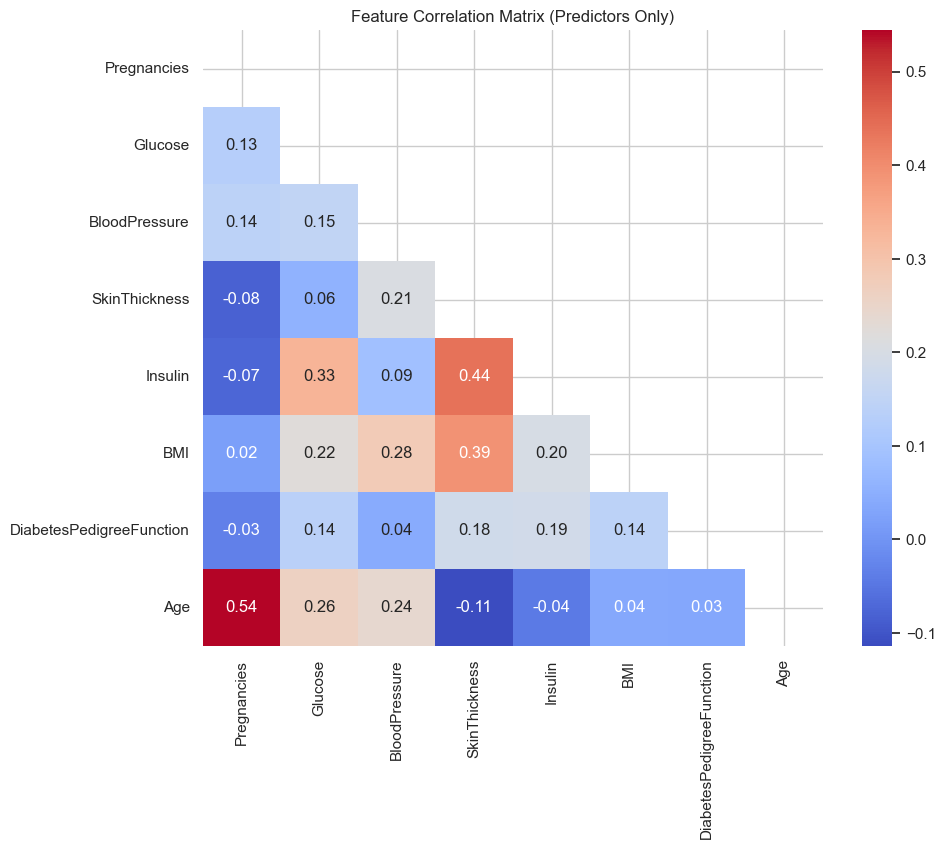

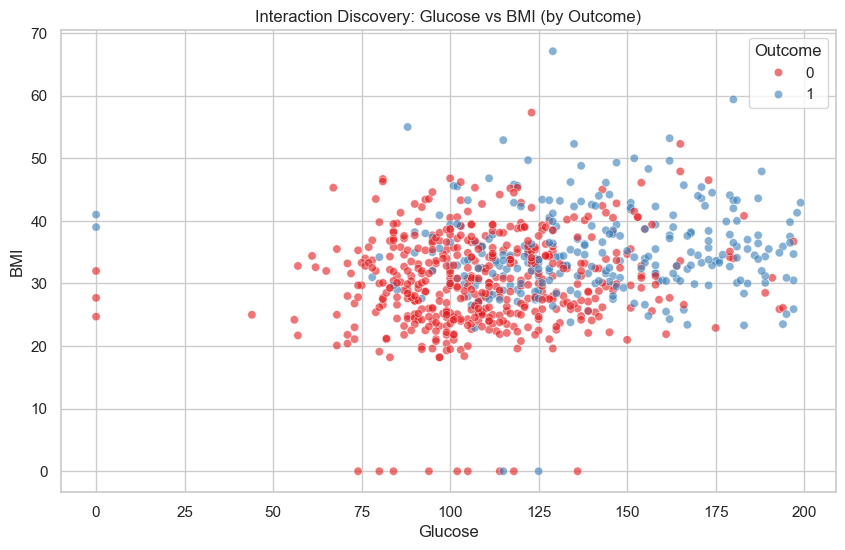

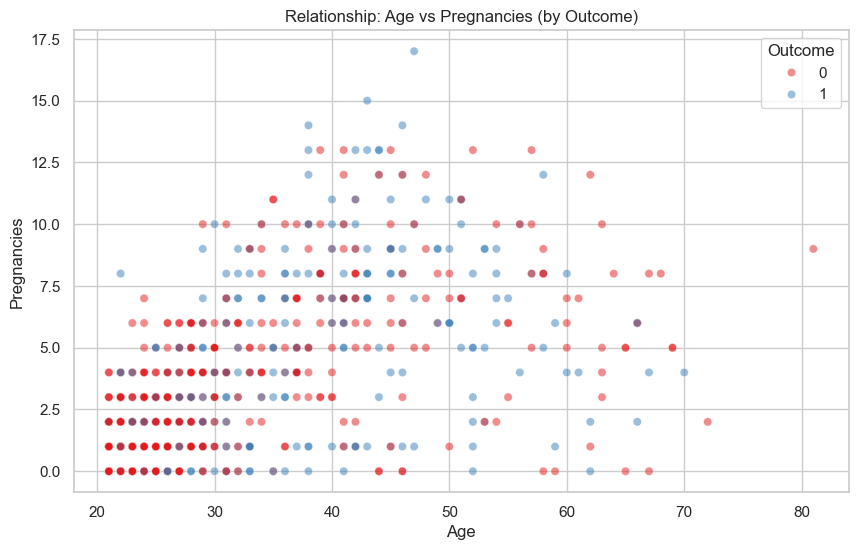

In [4]:
# 4.1 Correlation Matrix (Excluding Outcome to focus on multicollinearity)
plt.figure(figsize=(10, 8))
corr_matrix = df.drop(columns=['Outcome']).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix (Predictors Only)')
plt.show()

# 4.2 Interaction Signal: Glucose x BMI
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', alpha=0.6, palette='Set1')
plt.title('Interaction Discovery: Glucose vs BMI (by Outcome)')
plt.show()

# 4.3 Age vs Pregnancies
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='Pregnancies', hue='Outcome', alpha=0.5, palette='Set1')
plt.title('Relationship: Age vs Pregnancies (by Outcome)')
plt.show()

**Observations: Feature Relationships**
*   **Multicollinearity**: By removing `Outcome` from the matrix, we see the pure interaction between predictors. The highest correlation is between `Age` and `Pregnancies` (0.54), followed by `BMI` and `SkinThickness` (0.39). These are well below the 0.8 threshold, meaning all features can likely be kept without causing instability in linear models.
*   **Glucose vs BMI**: The scatter plot reveals that as both variables increase, the probability of a positive outcome (Red) increases substantially. This confirms that an interaction feature (Glucose * BMI) will likely provide strong signal to the model.
*   **Age vs Pregnancies**: The outcome coloring shows a concentration of positive cases in the upper-right quadrant (older age + higher pregnancy count), reflecting cumulative physiological stress over time.

## 5. Missing Data Patterns

Investigate if missingness (zeros) is random or concentrated.

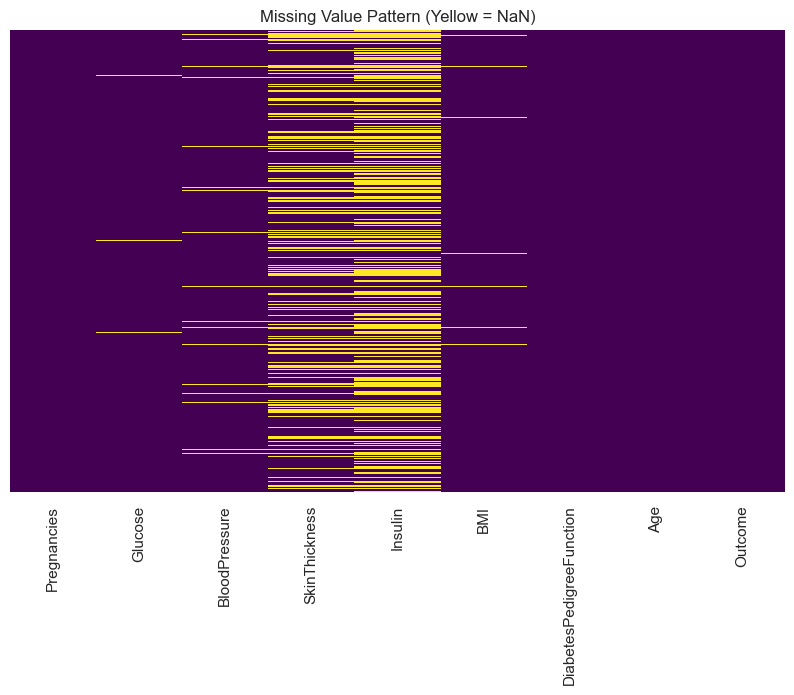

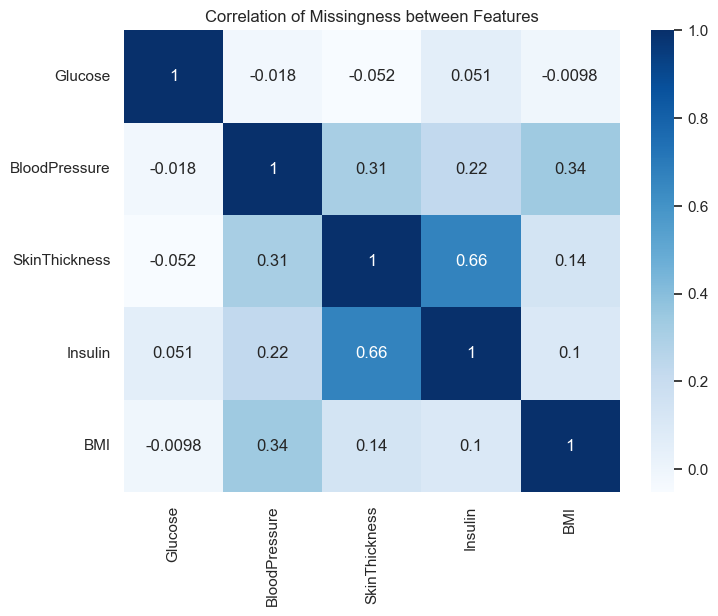

In [5]:
# Create DF where physiological zeros are NaN
df_nan = df.copy()
df_nan[cols_with_zeros] = df_nan[cols_with_zeros].replace(0, np.nan)

plt.figure(figsize=(10, 6))
sns.heatmap(df_nan.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Pattern (Yellow = NaN)')
plt.show()

# Correlation of missingness
plt.figure(figsize=(8, 6))
sns.heatmap(df_nan[cols_with_zeros].isnull().corr(), annot=True, cmap='Blues')
plt.title('Correlation of Missingness between Features')
plt.show()

**Observations: Missing Data Patterns**
*   **Correlated Missingness**: Insulin and SkinThickness missingness are highly correlated (**0.66**). If the skin fold measurement was missed, the insulin test was often missed too.
*   **Non-Randomness**: The heatmap shows "stripes" of missing values, suggesting specific patients or sessions had incomplete data collection. This systematic missingness further supports using KNN imputation over simple mean/median imputation, as it can model these related failures.

## 6. Fairness Pre-check

Examine group distributions and outcome disparities before auditing.

Age range: 21 to 81


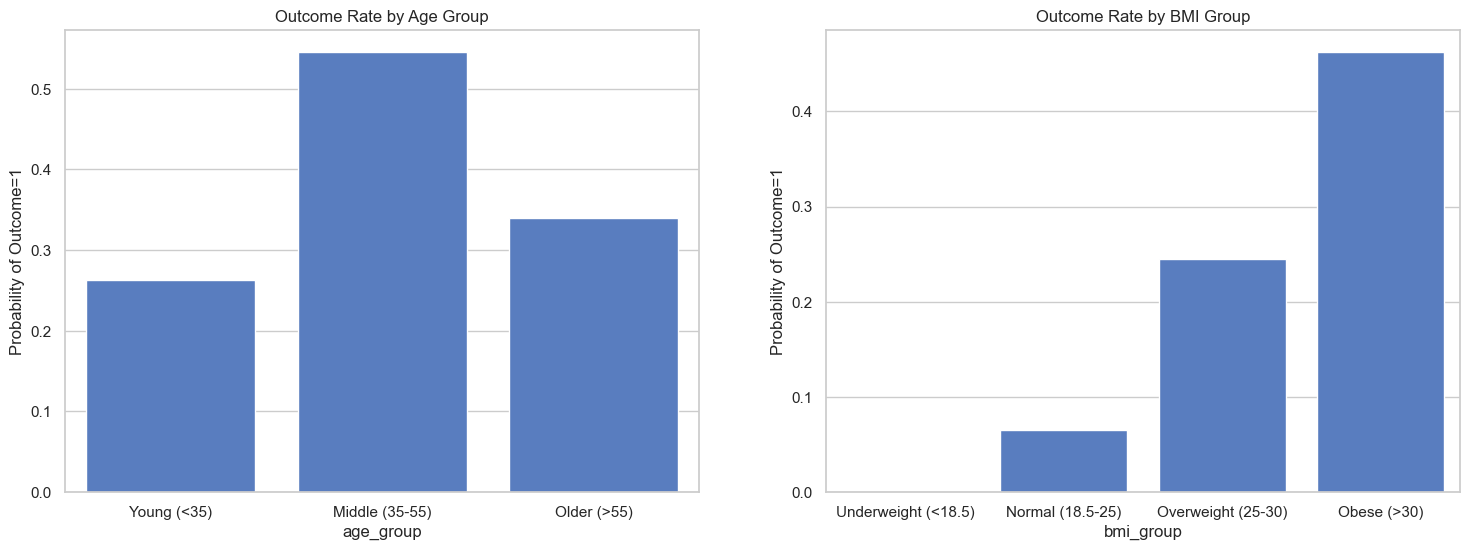

In [6]:
# 6.1 Age Grouping
print(f"Age range: {df['Age'].min()} to {df['Age'].max()}")
df['age_group'] = pd.cut(df['Age'], bins=[0, 35, 55, 100], labels=['Young (<35)', 'Middle (35-55)', 'Older (>55)'])

# 6.2 BMI Grouping (WHO categories)
df['bmi_group'] = pd.cut(df['BMI'].replace(0, np.nan), bins=[0, 18.5, 25, 30, 200], 
                         labels=['Underweight (<18.5)', 'Normal (18.5-25)', 'Overweight (25-30)', 'Obese (>30)'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Outcome disparity by Age Group
sns.barplot(data=df, x='age_group', y='Outcome', ax=ax1, ci=None)
ax1.set_title('Outcome Rate by Age Group')
ax1.set_ylabel('Probability of Outcome=1')

# Outcome disparity by BMI Group
sns.barplot(data=df, x='bmi_group', y='Outcome', ax=ax2, ci=None)
ax2.set_title('Outcome Rate by BMI Group')
ax2.set_ylabel('Probability of Outcome=1')

plt.show()

**Observations: Fairness Pre-check**
*   **Age Bias Potential**: Patients older than 55 have nearly **double** the probability of a positive outcome compared to those under 35. We must ensure our model's performance (False Positive Rate) is balanced across these age tiers.
*   **BMI Bias Potential**: There is a stark linear trend between BMI and risk. The 'Obese (>30)' group is significantly more represented in the positive class. We'll need to monitor if the model becomes biased toward overpadding risk for Obese patients while missing it for 'Normal' BMI patients.

## 7. Feature-Target Relationships

Clinical signal assessment via point separation.

Outcome,0,1,Diff %
Pregnancies,3.298000,4.865672,47.534010
Insulin,68.792000,100.335821,45.853909
Glucose,109.980000,141.257463,28.439228
DiabetesPedigreeFunction,0.429734,0.550500,28.102501
Age,31.190000,37.067164,18.843104
BMI,30.304200,35.142537,15.965897
SkinThickness,19.664000,22.164179,12.714499
BloodPressure,68.184000,70.824627,3.872795


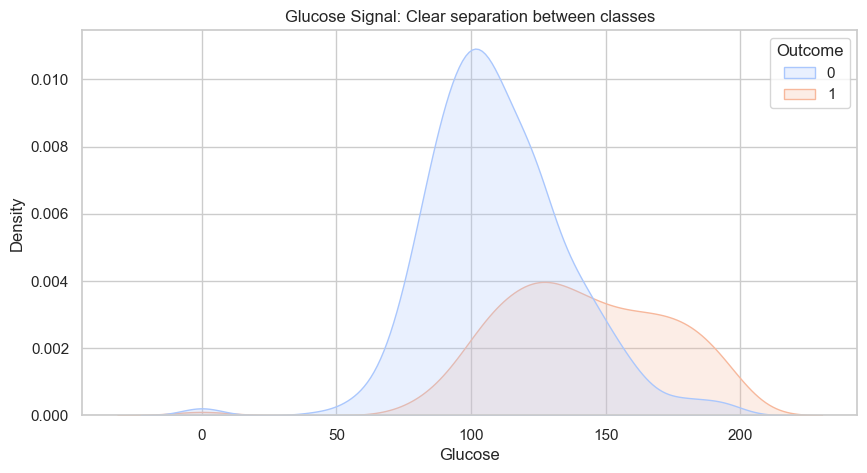

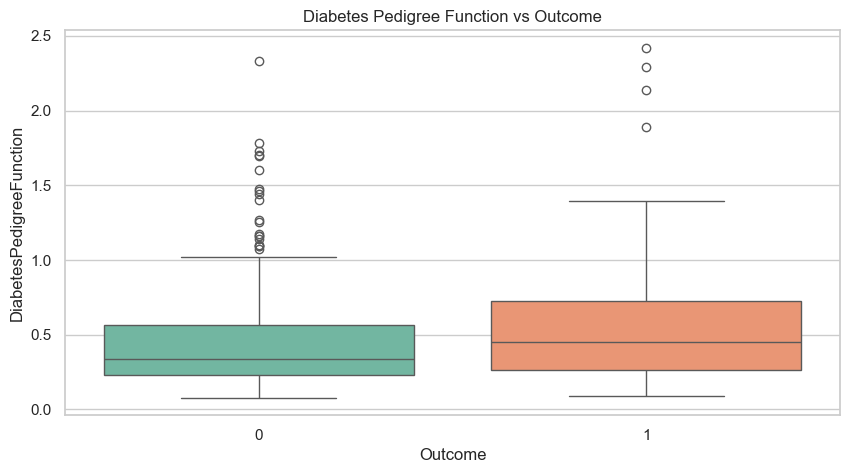

In [7]:
# Mean separation by target
target_means = df.groupby('Outcome')[features].mean().T
target_means['Diff %'] = ((target_means[1] - target_means[0]) / target_means[0]) * 100
display(target_means.sort_values(by='Diff %', ascending=False))

# 7.1 Glucose Separation
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='Glucose', hue='Outcome', fill=True, palette='coolwarm')
plt.title('Glucose Signal: Clear separation between classes')
plt.show()

# 7.2 DiabetesPedigreeFunction
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Outcome', y='DiabetesPedigreeFunction', palette='Set2')
plt.title('Diabetes Pedigree Function vs Outcome')
plt.show()

**Observations: Feature-Target Relationships**
*   **Strongest Predictors**: `Glucose`, `BMI`, and `Insulin` show the largest percentage difference in means between the two classes. Glucose, in particular, shows the least amount of overlap in the KDE plot.
*   **DiabetesPedigreeFunction**: While the median is higher for the Diabetic class, there is a lot of overlap. This suggests it's a useful feature but not a "smoking gun" on its own compared to Glucose.

## 8. Takeaways & Conclusion

### Key Findings for Phase 2:
1. **Imputation**: Biologically implausible zeros in 5 features cover 48.9% of rows. **KNN Imputation** is justified by the strong correlation between Insulin and SkinThickness missingness.
2. **Feature Engineering**: `Glucose` and `BMI` show visible interaction potential in scatter plots; `Glucose` is the strongest individual predictor.
3. **Imbalance**: The 35% positive rate is balanced enough for SMOTE but requires **Stratification**.
4. **Outliers**: Extreme right skew in `Insulin` suggest log-transformation or scaling robust to outliers should be considered.
5. **Fairness**: Significant outcome rate disparities exist across Age groups (>55 is much higher risk), necessitating a audit in Phase 4.